### Step 1: Import Libraries
Load `pandas`/`numpy` for data handling, `seaborn`/`matplotlib` for plotting, and `ttest_ind` from `scipy.stats` for the hypothesis test used later.

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

### Step 2: Load Dataset
Read the smartphone dataset from `Dataset.xlsx` into a DataFrame `df`.

In [ ]:
df = pd.read_excel('Dataset.xlsx')

### Step 3: Create Price Segments
Define a helper function that buckets each phone's `Price` into one of four categories — **Budget** (< 15,000), **Mid Range** (15,000–30,000), **Premium** (30,000–60,000), or **Ultra Premium** (60,000+) — and apply it to create a new `Price Segment` column.

In [4]:
def price_segment(price):

    if price < 15000:
        return "Budget"

    elif price < 30000:
        return "Mid Range"

    elif price < 60000:
        return "Premium"

    else:
        return "Ultra Premium"

df["Price Segment"] = df["Price"].apply(price_segment)

### Step 4: Check Dataset Size
Confirm the number of rows and columns in `df` after adding the segment column.

In [5]:
df.shape

(5627, 17)

### Step 5: Segment Counts
Count how many phones fall into each price segment.

In [6]:
df["Price Segment"].value_counts()

Price Segment
Budget           1951
Mid Range        1893
Premium          1001
Ultra Premium     782
Name: count, dtype: int64

### Step 6: Filter to Budget vs Premium
Keep only the **Budget** and **Premium** segments (dropping Mid Range and Ultra Premium) since the analysis compares these two groups.

In [7]:
analysis_df = df[
    df["Price Segment"].isin(["Budget", "Premium"])
].copy()

### Step 7: Verify Filtered Counts
Recheck segment counts after filtering to confirm only Budget and Premium remain.

In [8]:
analysis_df["Price Segment"].value_counts()

Price Segment
Budget     1951
Premium    1001
Name: count, dtype: int64

### Step 8: Mean Rating by Segment
Compute the average customer rating for each of the two segments.

In [9]:
analysis_df.groupby("Price Segment")["Rating"].mean()

Price Segment
Budget     4.187084
Premium    4.393407
Name: Rating, dtype: float64

### Step 9: Median Rating by Segment
Compute the median rating for each segment (less sensitive to outliers than the mean).

In [10]:
analysis_df.groupby("Price Segment")["Rating"].median()

Price Segment
Budget     4.2
Premium    4.4
Name: Rating, dtype: float64

### Step 10: Rating Standard Deviation by Segment
Measure the spread/variability of ratings within each segment.

In [11]:
analysis_df.groupby("Price Segment")["Rating"].std()

Price Segment
Budget     0.167752
Premium    0.195183
Name: Rating, dtype: float64

### Step 11: Full Descriptive Statistics
Generate count, mean, std, min, quartiles, and max for ratings in each segment in one summary table.

In [12]:
analysis_df.groupby("Price Segment")["Rating"].describe()

,count,mean,std,min,25%,50%,75%,max
Price Segment,,,,,,,,
Budget,1951.0,4.187084,0.167752,2.6,4.1,4.2,4.3,4.6
Premium,1001.0,4.393407,0.195183,2.3,4.3,4.4,4.5,4.8


### Step 12: Boxplot of Ratings
Visualize the rating distribution (median, IQR, outliers) for Budget vs Premium side by side.

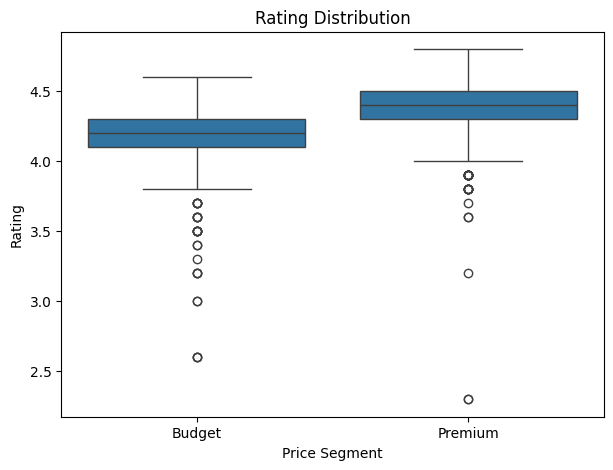

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=analysis_df,
    x="Price Segment",
    y="Rating"
)

plt.title("Rating Distribution")
plt.show()

### Step 13: Rating Histogram
Overlay histograms (with KDE curves) of ratings for both segments to compare their distribution shapes.

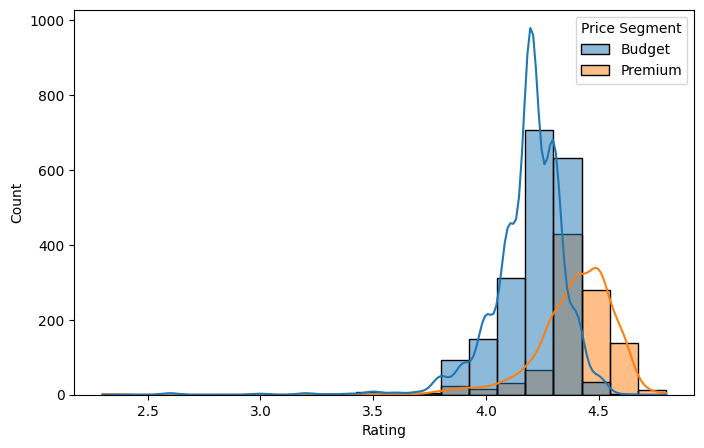

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=analysis_df,
    x="Rating",
    hue="Price Segment",
    bins=20,
    kde=True
)

plt.show()

### Step 14: Split Ratings by Group
Extract the `Rating` values into two separate arrays — `budget` and `premium` — for use in the statistical test.

In [15]:
budget = analysis_df.loc[
    analysis_df["Price Segment"] == "Budget",
    "Rating"
]

premium = analysis_df.loc[
    analysis_df["Price Segment"] == "Premium",
    "Rating"
]

### Step 15: Run Welch's t-test
Compare mean ratings between Budget and Premium groups using an independent two-sample t-test that does **not** assume equal variances (Welch's t-test).

In [16]:
t_stat, p_value = ttest_ind(
    budget,
    premium,
    equal_var=False
)

### Step 16: Print Test Results
Display the computed t-statistic and p-value from the test.

In [17]:
print("T Statistic :", t_stat)
print("P Value :", p_value)

T Statistic : -28.48011595336716
P Value : 3.3070105651323153e-147


### Step 17: Hypothesis Decision
Compare the p-value against the significance level (α = 0.05) and print whether the null hypothesis is rejected.

In [18]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


### Business Question

Do premium smartphones have better customer ratings than budget smartphones?

### Hypotheses

H₀:

There is no significant difference in the average ratings of budget and premium smartphones.

H₁:

There is a significant difference in the average ratings of budget and premium smartphones.

### Test Used

Independent Welch's t-test

### Results
Metric	Value
- Budget Mean	4.187084
- Premium Mean	4.393407
- t-statistic	-28.480
- p-value	3.30 × 10⁻¹⁴⁷

### Decision

Since the p-value is much smaller than 0.05, reject the null hypothesis.

### Business Insight

Premium smartphones have statistically significantly higher average customer ratings than budget smartphones. The observed difference is highly unlikely to be due to random chance, suggesting that customers generally report greater satisfaction with premium devices.